# 10 — Tiro a puerta (Definición y tiro a puerta)

Segunda tarea del catálogo, con la misma cinemática simple del kit (sin física, observación completa).
Código: `src/shooting_env.py` (entorno), `src/shooting_optimal.py` (óptimo exacto y calibración),
`src/task_train.py` (entrenamiento) y `src/task_analysis.py` (resúmenes con IC bootstrap).

**MDP** $\langle \mathcal{S}, \mathcal{A}, \mathcal{P}, R, \gamma \rangle$:

- **Inicio:** el atacante está sobre el balón a $d_g \sim U[11, 25]$ m de la línea de gol y en
  $y \sim U[-10, 10]$ m; arco de 14.02 m (postes en $y = \pm 7.01$). Con prob. 0.5 hay un arquero fijo en la línea,
  en $y_k \sim U[-3, 3]$ m. Se evalúa por separado **sin arquero** y **con arquero**.
- **Acciones (6):** tiro a 5 puntos de la línea de gol, $y^* \in \{-6, -3.5, 0, 3.5, 6\}$ m (poste izq., izq.,
  centro, der., poste der.), y `CONDUCIR` (+2 m hacia el arco, sin bajar de 11 m).
- **Transición:** el tiro sale con un error **angular** $\epsilon \sim \mathcal{N}(0, \sigma^2)$ respecto de la
  dirección al objetivo, así que el error lateral crece con la distancia real al punto (y la posición lateral
  importa: desde un costado el arco se ve más angosto). Cruza la línea en $y_c = y + d_g \tan(\varphi + \epsilon)$.
  Afuera si $|y_c| \ge 7.01$; atajado si hay arquero y $|y_c - y_k| < R$; si no, gol. Con arquero, cada
  `CONDUCIR` termina con prob. $p_{out}$ (el arquero sale y bloquea).
- **Recompensa:** $+100$ gol, $-30$ afuera, $-50$ atajado o bloqueado, $-0.2$ por `CONDUCIR`.
- **$\gamma = 0.99$**, $T_{max} = 10$ (el tiro termina el episodio).
- **Estados (36):** $d_g$ {11–15, 15–20, 20–25} m × lateral {izq. $y < -3.5$, centro, der. $y > 3.5$} ×
  arquero {sin, izq. $y_k < -1$, centro, der. $y_k > 1$}. Distancia y lateral determinan los ángulos a los postes
  $(\theta_{post\_l}, \theta_{post\_r})$ del enunciado.
- **Criterio:** gol > 75 % sin arquero y > 50 % con arquero.

In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
os.chdir("/workspace") if os.path.isdir("/workspace/src") else None
from src import plots, shooting_env as se
from src.task_analysis import load_condition
from src.task_train import get_task, run_episode
from src.agents import AGENTS

ART = "notebooks/artifacts"
RUNS = f"{ART}/runs_shooting"
DIAG = f"{ART}/runs_shooting_diag"
opt = json.load(open(f"{ART}/shooting_optimal.json"))
cal = json.load(open(f"{ART}/shooting_calibration.json"))
summary = json.load(open(f"{ART}/shooting_summary.json"))["conditions"]
alphas = json.load(open(f"{ART}/shooting_alphas.json"))
disc = se.default_discretizer()
SHORT = ["−6", "−3.5", "0", "+3.5", "+6", "COND"]
ACOLORS = ["#86b6ef", "#3987e5", "#c3c2b7", "#f4a582", "#eb6834", "#1baf7a"]
METHOD_ES = {"qlearning": "Q-Learning", "sarsa": "SARSA", "mc_first_visit": "MC (promedio)",
             "mc_first_visit_alpha": "MC (α constante)"}
SCHED_ES = {"eps_const_0.1": "ε const. 0.1", "eps_decay_1_to_0.1": "ε decreciente 1→0.1"}
NAMES = {"d_g": "distancia al arco", "y": "posición lateral", "keeper": "arquero"}
COLS = ["qlearning", "sarsa", "mc_first_visit_alpha", "mc_first_visit"]
def pct(x): return f"{100 * x:.1f} %"
def ci(s): return f"{pct(s['mean'])} [{100 * s['ci95'][0]:.1f}, {100 * s['ci95'][1]:.1f}]"

## 1. Calibración de parámetros y óptimo exacto

$\sigma$, $R$ y $p_{out}$ no vienen en el enunciado. Los fijamos **antes de entrenar** con una verificación de
estructura (no de un porcentaje objetivo) sobre el óptimo exacto: (a) el tiro óptimo cambia según la posición del
arquero; (b) `CONDUCIR` es óptimo en algún estado; (c) con arquero el óptimo no llega al 100 %. La grilla está
ordenada de más cercano a más lejano de la propuesta inicial ($\sigma = 4^\circ$, $R = 2$ m, $p_{out} = 0.1$) y se
elige el primer punto que pasa.

Las probabilidades de cada resultado son **exactas** (el punto de cruce es monótono en $\epsilon$, así que cada
resultado es un intervalo de $\epsilon$ y su probabilidad una diferencia de CDF normales; un test las contrasta con
simulación). El **óptimo verdadero** ve el estado continuo; el **óptimo de la representación** es la mejor política
determinista sobre nuestros 36 estados (lateral y arquero no cambian en el episodio, así que basta enumerar las
$6^3$ políticas por grupo).

In [2]:
rows = ["| σ (°) | R (m) | p_out | (a) | (b) | (c) | óptimo repr. con arquero |", "|---|---|---|---|---|---|---|"]
for g in cal["grid"]:
    p, c = g["params"], g["calibration"]
    mark = lambda b: "sí" if b else "**no**"
    rows.append(f"| {p['sigma_deg']:g} | {p['keeper_reach']:g} | {p['p_keeper_out']:g} | "
                f"{mark(c['a_shot_differs_across_keeper_bins'])} | {mark(c['b_conducir_optimal_somewhere'])} | "
                f"{mark(c['c_keeper_goal_rate_below_1'])} | {pct(g['evaluation']['keeper']['representation_optimum_goal_rate'])} |")
display(Markdown("\n".join(rows) + f"\n\nSeleccionado: `{cal['selected']}`"))
ev = opt["evaluation"]
display(Markdown("\n".join([
    "| evaluación (500 inicios fijos) | óptimo verdadero | óptimo de la representación | desv. muestral de una evaluación |",
    "|---|---|---|---|"] + [
    f"| {v} | {pct(e['true_optimum_goal_rate'])} | {pct(e['representation_optimum_goal_rate'])} | ± {pct(e['sampling_std_of_goal_rate'])} |"
    for v, e in ev.items()])))

| σ (°) | R (m) | p_out | (a) | (b) | (c) | óptimo repr. con arquero |
|---|---|---|---|---|---|---|
| 4 | 2 | 0.1 | sí | **no** | sí | 93.1 % |
| 4 | 2 | 0.05 | sí | **no** | sí | 93.1 % |
| 4 | 2 | 0.02 | sí | sí | sí | 93.3 % |
| 6 | 2 | 0.1 | sí | **no** | sí | 83.5 % |
| 6 | 2 | 0.05 | sí | **no** | sí | 83.5 % |
| 6 | 2 | 0.02 | sí | sí | sí | 84.8 % |
| 8 | 2 | 0.1 | sí | sí | sí | 73.7 % |
| 8 | 2 | 0.05 | sí | sí | sí | 73.7 % |
| 8 | 2 | 0.02 | sí | sí | sí | 76.9 % |

Seleccionado: `{'sigma_deg': 4.0, 'keeper_reach': 2.0, 'p_keeper_out': 0.02, 'p_keeper': 0.5}`

| evaluación (500 inicios fijos) | óptimo verdadero | óptimo de la representación | desv. muestral de una evaluación |
|---|---|---|---|
| open | 100.0 % | 100.0 % | ± 0.0 % |
| keeper | 95.2 % | 93.3 % | ± 1.1 % |

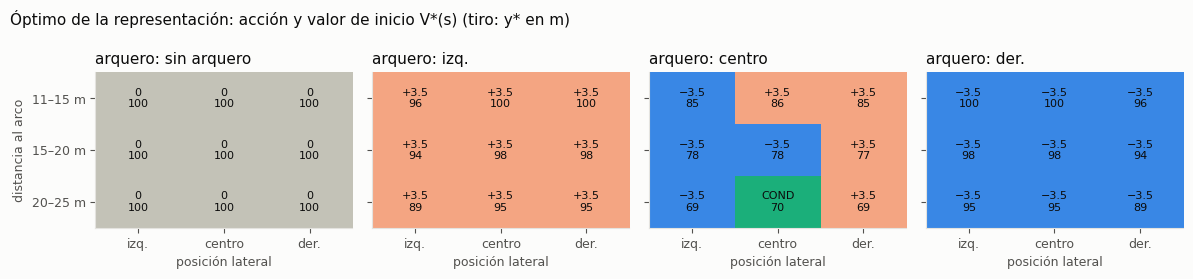

estados donde CONDUCIR es óptimo: ['d_g=20–25 m | y=centro | keeper=centro']
margen sobre la segunda mejor acción: [0.25]


In [3]:
actions = np.array(opt["representation_policy_actions"])
values = np.array([np.nan if v is None else v for v in opt["representation_start_values"]])
fig = plots.plot_policy_grid(actions, disc, row="d_g", col="y", facet="keeper", action_short=SHORT,
                             action_colors=ACOLORS, values=values, figsize=(12, 2.8), names=NAMES,
                             title="Óptimo de la representación: acción y valor de inicio V*(s) (tiro: y* en m)")
fig.savefig(f"{ART}/fig_shooting_optimal_policy.png", dpi=150, bbox_inches="tight")
plt.show()
margins = {lab: sorted(v["start_q"], reverse=True) for lab, v in opt["representation_policy"].items()}
cond = [lab for lab, v in opt["representation_policy"].items() if v["action"] == "CONDUCIR"]
print("estados donde CONDUCIR es óptimo:", cond)
print("margen sobre la segunda mejor acción:", [round(margins[l][0] - margins[l][1], 2) for l in cond])

La propuesta inicial falló (b): con $p_{out} = 0.1$ acercarse nunca compensa. La regla eligió $p_{out} = 0.02$,
sin tocar $\sigma$ ni $R$. Aun así `CONDUCIR` es óptimo en un solo estado y por un margen mínimo, y nunca conviene
apuntar al poste: **la tarea es, en la práctica, de una sola decisión** ("tirar a $\pm 3.5$ m, lejos del
arquero"). Lo decimos así en el informe; no cambiamos la regla después de ver el resultado. Sin arquero, tirar al
centro da prácticamente 100 %.

## 2. Ablación de exploración (Q-Learning)

Q-Learning, $\alpha$ elegido por barrido en semillas 5–9 (distintas de las reportadas 0–4), 50 000 episodios,
5 semillas. $\varepsilon$ constante 0.1 frente a $\varepsilon$ decreciente geométrico de 1.0 a 0.1 (llega al piso
al 60 % del presupuesto). Evaluación greedy cada 2 000 episodios sobre 500 inicios fijos por variante, con el mismo
ruido para todas las condiciones (números aleatorios comunes). Curvas: media de 5 semillas; banda: mínimo–máximo
entre semillas. Línea discontinua: óptimo de la representación.

α elegidos (barrido, semillas 5–9): {'mc_first_visit_alpha': 0.03, 'qlearning': 0.03, 'sarsa': 0.03}


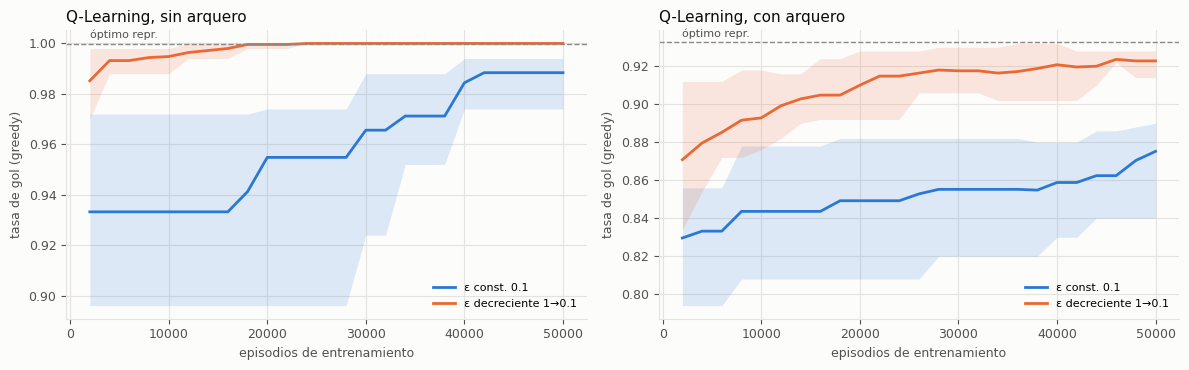

In [4]:
print("α elegidos (barrido, semillas 5–9):", alphas["alphas"])
q_runs = {c: load_condition(f"{RUNS}/shooting_qlearning_{c}") for c in ("eps_const_0.1", "eps_decay_1_to_0.1")}
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, v, name in zip(axes, ("open", "keeper"), ("sin arquero", "con arquero")):
    plots.plot_task_eval_curves(q_runs, v, ax=ax, labels=SCHED_ES, ylabel="tasa de gol (greedy)",
                                refs={"óptimo repr.": ev[v]["representation_optimum_goal_rate"]},
                                title=f"Q-Learning, {name}")
fig.tight_layout(); fig.savefig(f"{ART}/fig_shooting_ablation.png", dpi=150, bbox_inches="tight"); plt.show()

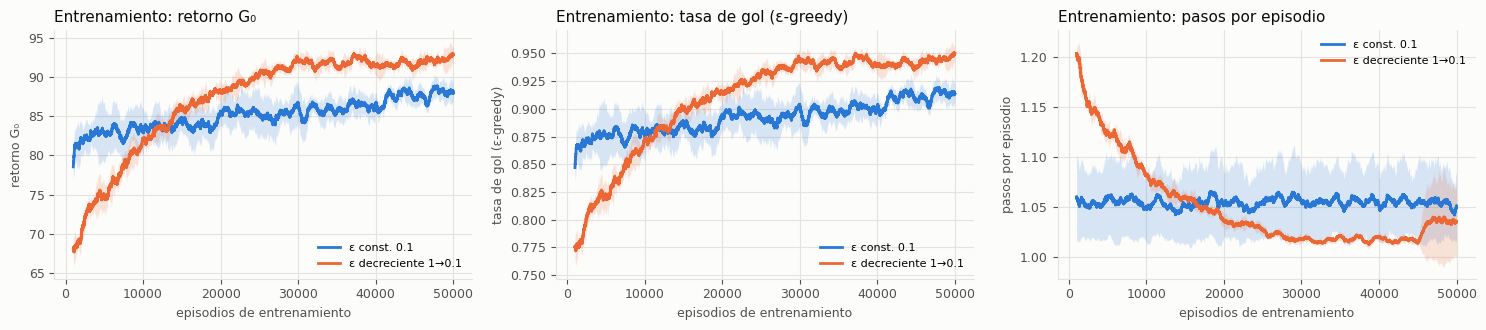

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))
for ax, key, ylab in zip(axes, ("discounted_return", "success", "steps"),
                         ("retorno G₀", "tasa de gol (ε-greedy)", "pasos por episodio")):
    plots.plot_training_curve(q_runs, key, window=1000, ax=ax, labels=SCHED_ES, ylabel=ylab,
                              title=f"Entrenamiento: {ylab}", direct_labels=False)
axes[2].legend(frameon=False, fontsize=8, loc="upper right")
fig.tight_layout(); fig.savefig(f"{ART}/fig_shooting_training.png", dpi=150, bbox_inches="tight"); plt.show()

## 3. Política y valor aprendidos

Q-Learning con $\varepsilon$ decreciente, semilla 0: acción greedy y $\hat V(s) = \max_a Q(s, a)$. Se compara con el
óptimo de la representación (§1).

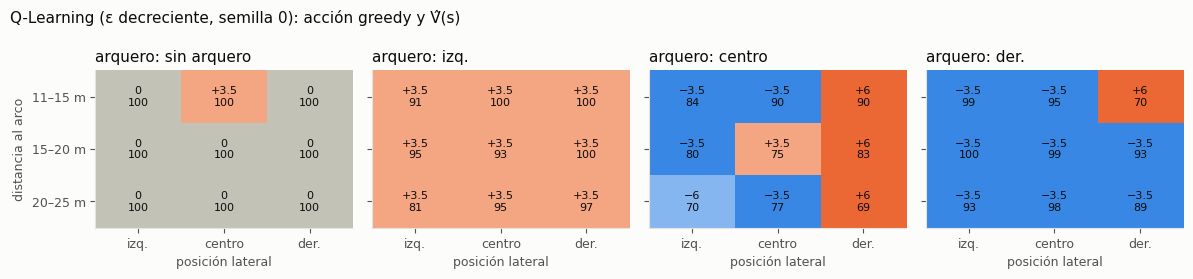

coincide con el óptimo de la representación en 27 de 36 estados


Estados donde difiere (diferencia = $Q^{\pi^*}(s, \text{óptima}) - Q^{\pi^*}(s, \text{aprendida})$, exacta, promediada sobre los inicios del estado; puede ser levemente negativa porque $\pi^*$ es óptima para todo el grupo, incluidos los estados a los que se llega con `CONDUCIR`):

| estado | aprendida | óptima | diferencia de valor |
|---|---|---|---|
| d_g=11–15 m | y=centro | keeper=sin arquero | +3.5 | 0 | 0.13 |
| d_g=11–15 m | y=centro | keeper=centro | −3.5 | +3.5 | 0.0 |
| d_g=11–15 m | y=der. | keeper=centro | +6 | +3.5 | 2.71 |
| d_g=11–15 m | y=der. | keeper=der. | +6 | −3.5 | 18.8 |
| d_g=15–20 m | y=centro | keeper=centro | +3.5 | −3.5 | -0.06 |
| d_g=15–20 m | y=der. | keeper=centro | +6 | +3.5 | 4.59 |
| d_g=20–25 m | y=izq. | keeper=centro | −6 | −3.5 | 4.69 |
| d_g=20–25 m | y=centro | keeper=centro | −3.5 | COND | 0.25 |
| d_g=20–25 m | y=der. | keeper=centro | +6 | +3.5 | 4.84 |

In [6]:
Q = q_runs["eps_decay_1_to_0.1"][0]["Q"]
fig = plots.plot_policy_grid(Q.argmax(1), disc, row="d_g", col="y", facet="keeper", action_short=SHORT,
                             action_colors=ACOLORS, values=Q.max(1), figsize=(12, 2.8), names=NAMES,
                             title="Q-Learning (ε decreciente, semilla 0): acción greedy y V̂(s)")
fig.savefig(f"{ART}/fig_shooting_learned_policy.png", dpi=150, bbox_inches="tight"); plt.show()
same = Q.argmax(1) == actions
print(f"coincide con el óptimo de la representación en {same.sum()} de 36 estados")
gap = [(disc.state_to_label(s), SHORT[Q.argmax(1)[s]], SHORT[actions[s]],
        round(opt['representation_policy'][disc.state_to_label(s)]['start_q'][actions[s]]
              - opt['representation_policy'][disc.state_to_label(s)]['start_q'][Q.argmax(1)[s]], 2))
       for s in np.flatnonzero(~same)]
display(Markdown("Estados donde difiere (diferencia = $Q^{\\pi^*}(s, \\text{óptima}) - Q^{\\pi^*}(s, \\text{aprendida})$, exacta, "
                 "promediada sobre los inicios del estado; puede ser levemente negativa porque $\\pi^*$ es óptima para todo el "
                 "grupo, incluidos los estados a los que se llega con `CONDUCIR`):\n\n" +
                 "\n".join(["| estado | aprendida | óptima | diferencia de valor |", "|---|---|---|---|"] +
                           [f"| {a} | {b} | {c} | {d} |" for a, b, c, d in gap])))

## 4. Trayectorias mientras aprende

Política greedy de las copias de la Q-table guardadas durante el entrenamiento (Q-Learning, $\varepsilon$
decreciente, semilla 0), sobre los mismos 12 inicios con arquero. Círculo: inicio; línea gris: `CONDUCIR`; línea
de color: tiro hasta la línea de gol; marca azul: posición del arquero de cada episodio (ataja a menos de 2 m).

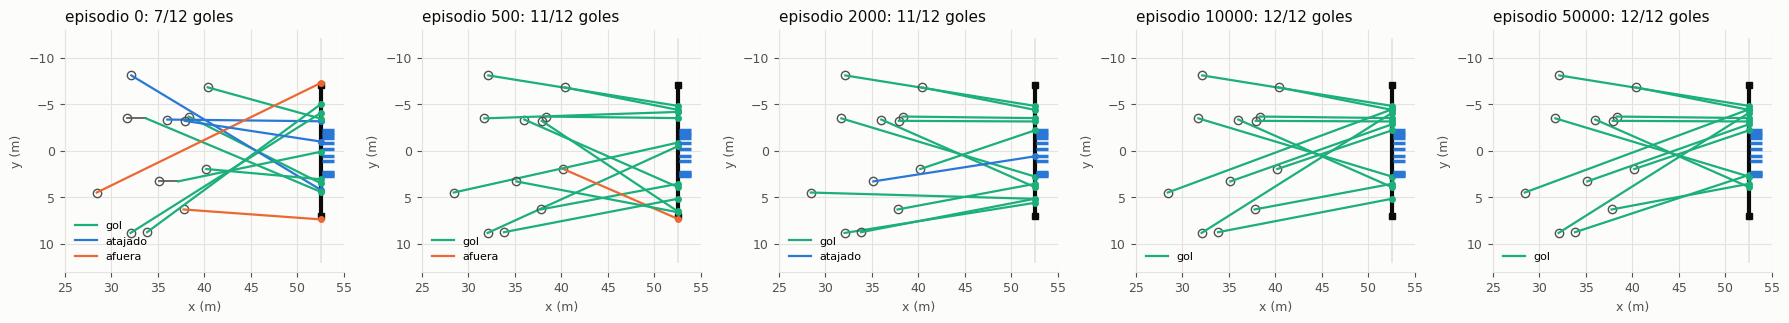

In [7]:
spec = get_task("shooting")
snaps = np.load(f"{RUNS}/shooting_qlearning_eps_decay_1_to_0.1/seed_0/q_snapshots.npz")
starts = se.evaluation_starts(500, 12345, "keeper")[:12]
env = se.ShootingEnv(seed=0)
eps_keys = sorted(snaps.files, key=lambda k: int(k.split("_")[1]))
fig, axes = plt.subplots(1, len(eps_keys), figsize=(3.6 * len(eps_keys), 4.2))
for ax, k in zip(axes, eps_keys):
    agent = AGENTS["qlearning"](disc.n_states, 6, seed=0); agent.Q = snaps[k].copy()
    env.rng = np.random.default_rng(7)
    recs = [run_episode(spec, env, agent, disc, 0.0, learn=False, start=s, record=True) for s in starts]
    goals = sum(r["success"] for r in recs)
    plots.plot_shooting_episodes(recs, ax=ax, reach=env.params.keeper_reach, show_reach=False,
                                 title=f"episodio {int(k.split('_')[1])}: {goals}/12 goles")
fig.tight_layout(); fig.savefig(f"{ART}/fig_shooting_learning_traj.png", dpi=150, bbox_inches="tight"); plt.show()

## 5. Criterio de éxito

Tasa de gol greedy al final (media de 5 semillas, IC 95 % bootstrap sobre semillas).

In [8]:
rows = ["| método | exploración | sin arquero (> 75 %) | con arquero (> 50 %) | cumple |", "|---|---|---|---|---|"]
for name, s in summary.items():
    if s["runs_dir"] != RUNS:
        continue
    o, k = s["variants"]["open"]["final"], s["variants"]["keeper"]["final"]
    sched = name.split("_eps_")[1]
    ok = min(o["per_seed"]) > 0.75 and min(k["per_seed"]) > 0.5
    rows.append(f"| {METHOD_ES[s['algorithm']]} | {SCHED_ES['eps_' + sched]} | {ci(o)} | {ci(k)} | "
                f"{'sí, en las 5 semillas' if ok else 'no'} |")
display(Markdown("\n".join(rows)))

| método | exploración | sin arquero (> 75 %) | con arquero (> 50 %) | cumple |
|---|---|---|---|---|
| MC (α constante) | ε const. 0.1 | 99.5 % [99.3, 99.7] | 86.2 % [84.9, 87.5] | sí, en las 5 semillas |
| MC (α constante) | ε decreciente 1→0.1 | 100.0 % [100.0, 100.0] | 91.7 % [89.7, 92.9] | sí, en las 5 semillas |
| MC (promedio) | ε const. 0.1 | 100.0 % [100.0, 100.0] | 93.3 % [92.6, 93.8] | sí, en las 5 semillas |
| MC (promedio) | ε decreciente 1→0.1 | 100.0 % [100.0, 100.0] | 92.9 % [92.4, 93.5] | sí, en las 5 semillas |
| Q-Learning | ε const. 0.1 | 98.8 % [98.1, 99.4] | 87.5 % [85.6, 88.8] | sí, en las 5 semillas |
| Q-Learning | ε decreciente 1→0.1 | 100.0 % [100.0, 100.0] | 92.3 % [91.8, 92.6] | sí, en las 5 semillas |
| SARSA | ε const. 0.1 | 98.8 % [98.1, 99.4] | 87.0 % [85.4, 88.4] | sí, en las 5 semillas |
| SARSA | ε decreciente 1→0.1 | 100.0 % [100.0, 100.0] | 92.5 % [91.8, 93.2] | sí, en las 5 semillas |

## 6. Comparación de métodos

Mismos estados, acciones, presupuesto, semillas e inicios de evaluación; solo cambia la regla de actualización.
Con $\varepsilon$ constante las curvas de Q-Learning y SARSA coinciden (la azul queda bajo la roja): los tiros
son terminales, así que las dos reglas solo difieren después de `CONDUCIR`. Métricas (con arquero): éxito greedy final; **AUC** = media del éxito greedy a lo largo del entrenamiento (mayor =
aprende antes); éxito $\varepsilon$-greedy del último 10 % del entrenamiento; sesgo de valor
$\overline{\max_a Q(s,a) - V^*(s)}$ y coincidencia con la política óptima de la representación (§1).

In [9]:
rows = ["| método | exploración | α | final con arquero | AUC | ε-greedy (último 10 %) | sesgo de valor | coincidencia con π* |",
        "|---|---|---|---|---|---|---|---|"]
for name, s in summary.items():
    if s["runs_dir"] != RUNS:
        continue
    k = s["variants"]["keeper"]
    sched = SCHED_ES["eps_" + name.split("_eps_")[1]]
    alpha = "1/N" if s["algorithm"] == "mc_first_visit" else f"{s['alpha']:g}"
    rows.append(f"| {METHOD_ES[s['algorithm']]} | {sched} | {alpha} | {ci(k['final'])} | {pct(k['auc']['mean'])} | "
                f"{pct(s['online_final']['mean'])} | {s['value_bias']['mean']:+.2f} | "
                f"{pct(s['policy_agreement']['mean'])} |")
display(Markdown("\n".join(rows)))

| método | exploración | α | final con arquero | AUC | ε-greedy (último 10 %) | sesgo de valor | coincidencia con π* |
|---|---|---|---|---|---|---|---|
| MC (α constante) | ε const. 0.1 | 0.03 | 86.2 % [84.9, 87.5] | 84.0 % | 91.3 % | -6.54 | 45.6 % |
| MC (α constante) | ε decreciente 1→0.1 | 0.03 | 91.7 % [89.7, 92.9] | 90.0 % | 94.5 % | -0.65 | 80.6 % |
| MC (promedio) | ε const. 0.1 | 1/N | 93.3 % [92.6, 93.8] | 92.5 % | 94.7 % | -0.22 | 84.4 % |
| MC (promedio) | ε decreciente 1→0.1 | 1/N | 92.9 % [92.4, 93.5] | 92.6 % | 94.6 % | +0.08 | 86.7 % |
| Q-Learning | ε const. 0.1 | 0.03 | 87.5 % [85.6, 88.8] | 85.1 % | 91.3 % | -6.64 | 46.1 % |
| Q-Learning | ε decreciente 1→0.1 | 0.03 | 92.3 % [91.8, 92.6] | 90.9 % | 94.6 % | -0.54 | 78.3 % |
| SARSA | ε const. 0.1 | 0.03 | 87.0 % [85.4, 88.4] | 85.1 % | 91.3 % | -6.70 | 46.1 % |
| SARSA | ε decreciente 1→0.1 | 0.03 | 92.5 % [91.8, 93.2] | 90.5 % | 94.7 % | -0.52 | 80.0 % |

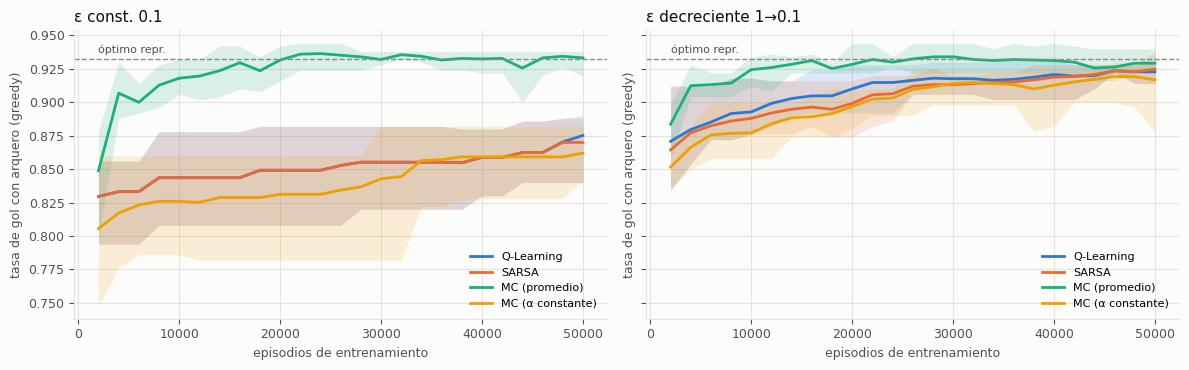

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, sched in zip(axes, ("eps_const_0.1", "eps_decay_1_to_0.1")):
    runs = {m: load_condition(f"{RUNS}/shooting_{m}_{sched}") for m in METHOD_ES}
    plots.plot_task_eval_curves(runs, "keeper", ax=ax, labels=METHOD_ES, ylabel="tasa de gol con arquero (greedy)",
                                refs={"óptimo repr.": ev["keeper"]["representation_optimum_goal_rate"]},
                                title=SCHED_ES[sched])
fig.tight_layout(); fig.savefig(f"{ART}/fig_shooting_methods.png", dpi=150, bbox_inches="tight"); plt.show()

## 7. Diagnóstico: ¿por qué $\varepsilon$ constante queda atrás con $\alpha$ constante?

Con $\varepsilon$ constante, los tres métodos de paso constante quedan por debajo de MC con promedios, y su
$\max_a Q$ **subestima** $V^*$. Hipótesis: $Q$ empieza en 0 y los valores reales rondan 70–100; con $\alpha = 0.03$
cada actualización mueve $Q$ un 3 %, y con $\varepsilon = 0.1$ cada acción no greedy recibe ~1.7 % de las visitas,
así que una elección greedy temprana equivocada se corrige lento. MC con promedios fija $Q$ en el retorno completo
en la primera visita. Si la hipótesis es correcta, cualquiera de estos cambios debería cerrar la brecha: $\alpha$
mayor (D1), valores iniciales optimistas $Q_0 = 100$ (D2) o 4 veces más episodios (D3). Mismas semillas (0–4) e
inicios.

In [11]:
def cell(name):
    s = summary[name]["variants"]["keeper"]["final"]
    return ci(s)
rows = ["| condición (ε const. 0.1) | " + " | ".join(METHOD_ES[m] for m in COLS) + " |", "|---|---|---|---|---|"]
rows.append("| reportada: α elegido, Q₀ = 0 | " + " | ".join(cell(f"shooting_{m}_eps_const_0.1") for m in COLS) + " |")
for a in (0.1, 0.3):
    rows.append(f"| D1: α = {a:g} | " + " | ".join(cell(f"shooting_diag_step_{m}_alpha{a:g}")
                                               for m in ("qlearning", "sarsa", "mc_first_visit_alpha")) + " | — |")
rows.append("| D2: Q₀ = 100 | " + " | ".join(cell(f"shooting_diag_optinit_{m}") for m in COLS) + " |")
rows.append("| D3: 4× episodios | " + " | ".join(cell(f"shooting_diag_budget4x_{m}")
                                               for m in ("qlearning", "sarsa", "mc_first_visit_alpha")) + " | — |")
rows.append("| *ref.: ε decreciente, α elegido* | " + " | ".join(cell(f"shooting_{m}_eps_decay_1_to_0.1") for m in COLS) + " |")
display(Markdown("\n".join(rows)))

| condición (ε const. 0.1) | Q-Learning | SARSA | MC (α constante) | MC (promedio) |
|---|---|---|---|---|
| reportada: α elegido, Q₀ = 0 | 87.5 % [85.6, 88.8] | 87.0 % [85.4, 88.4] | 86.2 % [84.9, 87.5] | 93.3 % [92.6, 93.8] |
| D1: α = 0.1 | 91.9 % [90.4, 92.8] | 91.0 % [89.8, 92.0] | 92.4 % [91.8, 93.0] | — |
| D1: α = 0.3 | 90.8 % [89.1, 92.2] | 89.9 % [89.2, 90.7] | 91.2 % [90.0, 92.6] | — |
| D2: Q₀ = 100 | 91.1 % [89.7, 92.4] | 92.6 % [91.8, 93.4] | 92.9 % [91.8, 93.9] | 93.5 % [92.4, 94.5] |
| D3: 4× episodios | 92.1 % [91.1, 93.2] | 91.8 % [91.1, 92.5] | 93.2 % [92.4, 93.9] | — |
| *ref.: ε decreciente, α elegido* | 92.3 % [91.8, 92.6] | 92.5 % [91.8, 93.2] | 91.7 % [89.7, 92.9] | 92.9 % [92.4, 93.5] |

## Figura para el informe

(a) Ablación de exploración de Q-Learning con arquero; (b) los cuatro métodos con $\varepsilon$ constante;
(c, d) tiros de la política greedy de Q-Learning ($\varepsilon$ decreciente, semilla 0) al inicio y al final del
entrenamiento, sobre los mismos 12 inicios con arquero.

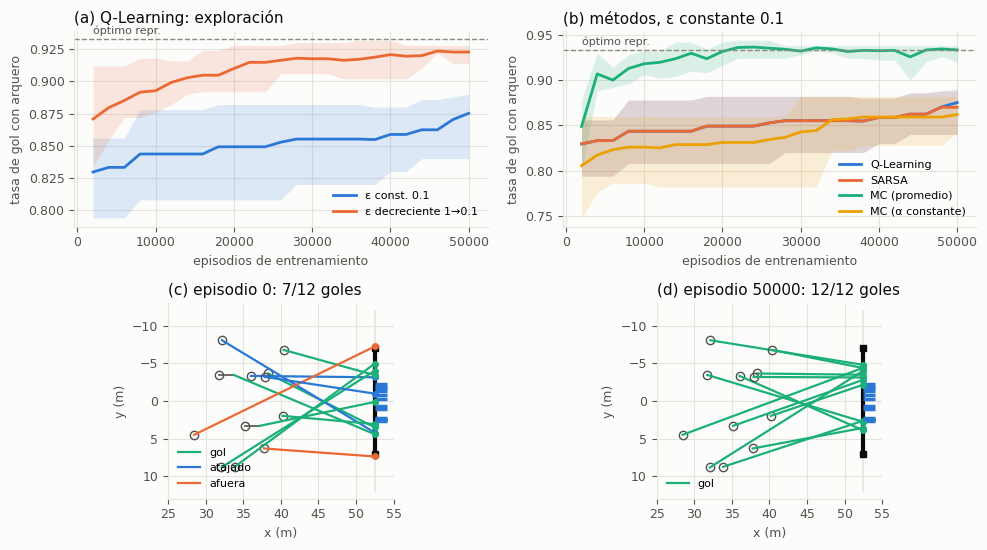

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 5.6))
plots.plot_task_eval_curves(q_runs, "keeper", ax=axes[0, 0], labels=SCHED_ES, ylabel="tasa de gol con arquero",
                            refs={"óptimo repr.": ev["keeper"]["representation_optimum_goal_rate"]},
                            title="(a) Q-Learning: exploración")
runs = {m: load_condition(f"{RUNS}/shooting_{m}_eps_const_0.1") for m in METHOD_ES}
plots.plot_task_eval_curves(runs, "keeper", ax=axes[0, 1], labels=METHOD_ES, ylabel="tasa de gol con arquero",
                            refs={"óptimo repr.": ev["keeper"]["representation_optimum_goal_rate"]},
                            title="(b) métodos, ε constante 0.1")
for ax, k, tag in ((axes[1, 0], eps_keys[0], "(c)"), (axes[1, 1], eps_keys[-1], "(d)")):
    agent = AGENTS["qlearning"](disc.n_states, 6, seed=0); agent.Q = snaps[k].copy()
    env.rng = np.random.default_rng(7)
    recs = [run_episode(spec, env, agent, disc, 0.0, learn=False, start=s, record=True) for s in starts]
    plots.plot_shooting_episodes(recs, ax=ax, reach=env.params.keeper_reach, show_reach=False,
                                 title=f"{tag} episodio {int(k.split('_')[1])}: {sum(r['success'] for r in recs)}/12 goles")
fig.tight_layout(); fig.savefig(f"{ART}/fig_report_shooting.png", dpi=200, bbox_inches="tight"); plt.show()

## 8. Conclusiones

Todos los números citados están en las tablas de arriba (IC 95 % bootstrap sobre 5 semillas; una diferencia se
declara solo si los IC no se solapan, un criterio grueso con 5 semillas).

- **Criterio:** las 8 condiciones lo cumplen en cada una de las 5 semillas; las medias son ≥ 98.8 % sin arquero y
  ≥ 86.2 % con arquero (umbrales 75 % y 50 %). El mejor resultado con arquero (≈ 93 %) está al nivel del óptimo de la representación
  (93.3 %, ± 1.1 % de ruido muestral de una evaluación); el óptimo verdadero, con el estado continuo, es 95.2 %.
- **Estructura de la tarea:** con los parámetros calibrados, la tarea es casi de una sola decisión: tirar a
  ±3.5 m del lado contrario al arquero. `CONDUCIR` solo es óptimo en un estado y por 0.25 puntos.
- **Exploración (Q-Learning):** con α = 0.03, ε decreciente termina más alto que ε constante (92.3 % frente a
  87.5 % con arquero, IC separados). Pero el diagnóstico muestra que es **velocidad, no la solución final**: con
  ε constante la brecha se cierra (IC solapados con ε decreciente) con α = 0.1, con Q₀ = 100 o con 4 veces más
  episodios. Con Q₀ = 0 y pasos pequeños, los valores parten 70–100 puntos por debajo (sesgo final de −6.6) y
  ε = 0.1 visita poco las acciones no greedy, así que corregirlas toma mucho. ε decreciente explora todas las
  acciones al principio. La conclusión de la ablación depende entonces de α, y así la reportamos.
- **Métodos:** Q-Learning y SARSA son equivalentes aquí por construcción (tiros terminales: mismo objetivo de
  actualización). **MC con promedios** es el mejor con ε constante (93.3 % frente a 86–88 %) y el que aprende antes
  con ε decreciente (AUC 92.6 % frente a 90.9 % de Q-Learning, IC separados), aunque al final con ε decreciente no
  hay diferencia detectable entre los cuatro. Explicación respaldada por D2/D3: el paso 1/N fija Q en el primer
  retorno observado y luego da el promedio muestral, que es el estimador natural de un resultado terminal
  estacionario; no arrastra el valor inicial como los métodos de α constante.
- **Sesgo de maximización (hipótesis H1): no observado.** Los sesgos de valor van de −6.7 a +0.08, y el de
  Q-Learning no es mayor que el de SARSA (−0.54 frente a −0.52 con ε decreciente). En esta tarea la maximización de Q-Learning casi no actúa, porque solo entra en el objetivo después de
  `CONDUCIR`; lo que domina es la subestimación por Q₀ = 0.